# Exploración del modelo
## Aprendizaje Profundo - PCIC
### Eduardo García Alarcón 2025-1

In [36]:
import numpy as np
from matplotlib import pyplot as plt
import speechbrain as sb
import torch as th
from tqdm import tqdm, trange
import torchaudio

SEED = 42
np.random.seed(SEED)
th.manual_seed(SEED)

In [5]:
from speechbrain.inference.classifiers import EncoderClassifier
classifier = EncoderClassifier.from_hparams(source="speechbrain/urbansound8k_ecapa", savedir="pretrained_models/gurbansound8k_ecapa")

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/urbansound8k_ecapa' if not cached


INFO:speechbrain.utils.fetching:Fetch custom.py: Fetching from HuggingFace Hub 'speechbrain/urbansound8k_ecapa' if not cached
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/urbansound8k_ecapa' if not cached
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Fetching from HuggingFace Hub 'speechbrain/urbansound8k_ecapa' if not cached
INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/urbansound8k_ecapa' if not cached
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, classifier, label_encoder


In [8]:
classifier.modules

<bound method Module.modules of EncoderClassifier(
  (mods): ModuleDict(
    (compute_features): Fbank(
      (compute_STFT): STFT()
      (compute_fbanks): Filterbank()
      (compute_deltas): Deltas()
      (context_window): ContextWindow()
    )
    (mean_var_norm): InputNormalization()
    (embedding_model): ECAPA_TDNN(
      (blocks): ModuleList(
        (0): TDNNBlock(
          (conv): Conv1d(
            (conv): Conv1d(80, 1024, kernel_size=(5,), stride=(1,))
          )
          (activation): ReLU()
          (norm): BatchNorm1d(
            (norm): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
        (1): SERes2NetBlock(
          (tdnn1): TDNNBlock(
            (conv): Conv1d(
              (conv): Conv1d(1024, 1024, kernel_size=(1,), stride=(1,))
            )
            (activation): ReLU()
            (norm): BatchNorm1d(
              (norm): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running

## Obtenemos el data set
### AudioSet

In [9]:
import os
import pandas as pd
from yt_dlp import YoutubeDL

In [2]:
from audioset_download import Downloader

In [3]:
help(Downloader)

Help on class Downloader in module audioset_download.Downloader:

class Downloader(builtins.object)
 |  Downloader(root_path: str, labels: list = None, n_jobs: int = 1, download_type: str = 'unbalanced_train', copy_and_replicate: bool = True)
 |  
 |  This class implements the download of the AudioSet dataset.
 |  It only downloads the audio files according to the provided list of labels and associated timestamps.
 |  
 |  Methods defined here:
 |  
 |  __init__(self, root_path: str, labels: list = None, n_jobs: int = 1, download_type: str = 'unbalanced_train', copy_and_replicate: bool = True)
 |      This method initializes the class.
 |      :param root_path: root path of the dataset
 |      :param labels: list of labels to download
 |      :param n_jobs: number of parallel jobs
 |      :param download_type: type of download (unbalanced_train, balanced_train, eval)
 |      :param copy_and_replicate: if True, the audio file is copied and replicated for each label. 
 |                 

### Clases de UrbanSound
- 0 = dog_bark
- 1 = children_playing
- 2 = air_conditioner
- 3 = street_music
- 4 = gun_shot
- 5 = siren
- 6 = engine_idling
- 7 = jackhammer
- 8 = drilling
- 9 = car_horn

In [10]:
lable_to_code = {
  'Bark': '/m/05tny_', 
  'Children playing': '/t/dd00013',
  'Air conditioning': '/m/025wky1',
  # 'Music',
  'Gunshot, gunfire': '/m/032s66',
  'Police car (siren)': '/m/04qvtq', 'Ambulance (siren)': '/m/012n7d',
  'Engine': '/m/02mk9',
  'Jackhammer': '/m/03p19w',
  'Drill': '/m/01d380',
  'Vehicle horn, car horn, honking': '/m/0912c9',
}

In [ ]:
d = Downloader('./Data/AudioSet/', labels=[key for key in lable_to_code.keys()], n_jobs=3, download_type='balanced_train', copy_and_replicate=False)

In [10]:
d.download(format='wav')

[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.


[youtube] Extracting URL: https://www.youtube.com/watch?v=-2PDE7hUArE
[youtube] -2PDE7hUArE: Downloading webpage
[youtube] Extracting URL: https://www.youtube.com/watch?v=--aaILOrkII
[youtube] --aaILOrkII: Downloading webpage
[youtube] Extracting URL: https://www.youtube.com/watch?v=-4RWqM0UCCY
[youtube] -4RWqM0UCCY: Downloading webpage
[youtube] -2PDE7hUArE: Downloading ios player API JSON
[youtube] --aaILOrkII: Downloading ios player API JSON
[youtube] -4RWqM0UCCY: Downloading ios player API JSON
[youtube] -2PDE7hUArE: Downloading mweb player API JSON
[youtube] --aaILOrkII: Downloading mweb player API JSON
[youtube] -4RWqM0UCCY: Downloading mweb player API JSON
[youtube] -4RWqM0UCCY: Downloading m3u8 information
[info] -4RWqM0UCCY: Downloading 1 format(s): 140
[youtube] --aaILOrkII: Downloading m3u8 information
[youtube] -2PDE7hUArE: Downloading m3u8 information
[info] -2PDE7hUArE: Downloading 1 format(s): 140
[download] Destination: ./Data/AudioSet/Ambulance (siren)/-4RWqM0UCCY_0.0-

[Parallel(n_jobs=3)]: Done   2 tasks      | elapsed:    3.5s


[youtube] Extracting URL: https://www.youtube.com/watch?v=-75IwDlkzDQ
[youtube] -75IwDlkzDQ: Downloading webpage
[ExtractAudio] Destination: ./Data/AudioSet/Gunshot, gunfire/--aaILOrkII_200.0-210.0.wav
[youtube] Extracting URL: https://www.youtube.com/watch?v=-7J4109yM7w
[youtube] -7J4109yM7w: Downloading webpage
Deleting original file ./Data/AudioSet/Gunshot, gunfire/--aaILOrkII_200.0-210.0.m4a (pass -k to keep)


[youtube] Extracting URL: https://www.youtube.com/watch?v=-DNkAalo7og
[youtube] -DNkAalo7og: Downloading webpage
[youtube] -75IwDlkzDQ: Downloading ios player API JSON
[youtube] -7J4109yM7w: Downloading ios player API JSON
[youtube] -75IwDlkzDQ: Downloading mweb player API JSON
[youtube] -7J4109yM7w: Downloading mweb player API JSON
[youtube] -DNkAalo7og: Downloading ios player API JSON
[youtube] -DNkAalo7og: Downloading mweb player API JSON
[youtube] -75IwDlkzDQ: Downloading m3u8 information
[info] -75IwDlkzDQ: Downloading 1 format(s): 140
[youtube] -DNkAalo7og: Downloading m3u8 information
[download] Destination: ./Data/AudioSet/Engine knocking/-75IwDlkzDQ_30.0-40.0.m4a
[download]   2.8% of    2.23MiB at    1.75MiB/s ETA 00:01[info] -DNkAalo7og: Downloading 1 format(s): 140
[download]   5.6% of    2.23MiB at    2.11MiB/s ETA 00:00[youtube] -7J4109yM7w: Downloading m3u8 information
[download] 100% of    2.23MiB in 00:00:00 at 3.18MiB/s   
[FixupM4a] Correcting container of "./Data/Aud

...

ERROR: [youtube] zjk9aUW5c_0: Video unavailable. This video is no longer available because the YouTube account associated with this video has been terminated.


[download] Destination: ./Data/AudioSet/Speech/zj0wawtfZsA_10.0-20.0.webm
[download]  35.7% of    2.80MiB at    7.54MiB/s ETA 00:00[youtube] Extracting URL: https://www.youtube.com/watch?v=znWyOGuH4EY
[youtube] znWyOGuH4EY: Downloading webpage
[info] zHy43cBfK9M: Downloading 1 format(s): 140
[download] 100% of    2.80MiB in 00:00:00 at 3.64MiB/s   
[ExtractAudio] Destination: ./Data/AudioSet/Speech/zj0wawtfZsA_10.0-20.0.wav
[download] Destination: ./Data/AudioSet/Gunshot, gunfire/zHy43cBfK9M_30.0-40.0.m4a
[download]   0.3% of    4.89MiB at    2.93MiB/s ETA 00:01Deleting original file ./Data/AudioSet/Speech/zj0wawtfZsA_10.0-20.0.webm (pass -k to keep)
[download]   1.3% of    4.89MiB at  830.61KiB/s ETA 00:05[youtube] znWyOGuH4EY: Downloading ios player API JSON
[download]  10.2% of    4.89MiB at    2.21MiB/s ETA 00:01[youtube] Extracting URL: https://www.youtube.com/watch?v=zu53y8M2xBc
[youtube] zu53y8M2xBc: Downloading webpage
[download]  20.4% of    4.89MiB at    3.48MiB/s ETA 00:01

[youtube] znWyOGuH4EY: Downloading mweb player API JSON
[download]  40.9% of    4.89MiB at    5.25MiB/s ETA 00:00[youtube] zu53y8M2xBc: Downloading ios player API JSON
[download] 100% of    4.89MiB in 00:00:01 at 3.57MiB/s   
[FixupM4a] Correcting container of "./Data/AudioSet/Gunshot, gunfire/zHy43cBfK9M_30.0-40.0.m4a"
[youtube] zu53y8M2xBc: Downloading mweb player API JSON
[ExtractAudio] Destination: ./Data/AudioSet/Gunshot, gunfire/zHy43cBfK9M_30.0-40.0.wav
Deleting original file ./Data/AudioSet/Gunshot, gunfire/zHy43cBfK9M_30.0-40.0.m4a (pass -k to keep)
[youtube] znWyOGuH4EY: Downloading m3u8 information
[youtube] Extracting URL: https://www.youtube.com/watch?v=zz8TGV83nkE
[youtube] zz8TGV83nkE: Downloading webpage


[info] znWyOGuH4EY: Downloading 1 format(s): 140
[youtube] zu53y8M2xBc: Downloading m3u8 information
[info] zu53y8M2xBc: Downloading 1 format(s): 140
[youtube] zz8TGV83nkE: Downloading ios player API JSON
[download] Destination: ./Data/AudioSet/Drill/znWyOGuH4EY_230.0-240.0.m4a
[download]   1.4% of    8.75MiB at    1.22MiB/s ETA 00:07[download] Destination: ./Data/AudioSet/Gunshot, gunfire/zu53y8M2xBc_20.0-30.0.m4a
[download]   3.1% of  490.67KiB at    2.06MiB/s ETA 00:00[youtube] zz8TGV83nkE: Downloading mweb player API JSON
[download] 100% of  490.67KiB in 00:00:00 at 668.80KiB/s 
[FixupM4a] Correcting container of "./Data/AudioSet/Gunshot, gunfire/zu53y8M2xBc_20.0-30.0.m4a"
[ExtractAudio] Destination: ./Data/AudioSet/Gunshot, gunfire/zu53y8M2xBc_20.0-30.0.wav
[download]  45.7% of    8.75MiB at    6.49MiB/s ETA 00:00Deleting original file ./Data/AudioSet/Gunshot, gunfire/zu53y8M2xBc_20.0-30.0.m4a (pass -k to keep)
[download] 100% of    8.75MiB in 00:00:01 at 4.92MiB/s   
[FixupM4a] C

[Parallel(n_jobs=3)]: Done 818 out of 818 | elapsed: 16.7min finished


In [11]:
code_to_lable  = {item: key for key, item in lable_to_code.items()}

In [12]:
code_to_lable

{'/m/05tny_': 'Bark',
 '/t/dd00013': 'Children playing',
 '/m/025wky1': 'Air conditioning',
 '/m/032s66': 'Gunshot, gunfire',
 '/m/04qvtq': 'Police car (siren)',
 '/m/012n7d': 'Ambulance (siren)',
 '/m/02mk9': 'Engine',
 '/m/03p19w': 'Jackhammer',
 '/m/01d380': 'Drill',
 '/m/0912c9': 'Vehicle horn, car horn, honking'}

In [39]:
code_to_indx = {key: i for i, key in enumerate(code_to_lable.keys())}

In [69]:
indx_to_lable = {}
for code, indx in code_to_indx.items():
    indx_to_lable[indx] = code_to_lable[code]

In [70]:
indx_to_lable

{0: 'Bark',
 1: 'Children playing',
 2: 'Air conditioning',
 3: 'Gunshot, gunfire',
 4: 'Police car (siren)',
 5: 'Ambulance (siren)',
 6: 'Engine',
 7: 'Jackhammer',
 8: 'Drill',
 9: 'Vehicle horn, car horn, honking'}

In [68]:
code_to_indx.items()

dict_items([('/m/05tny_', 0), ('/t/dd00013', 1), ('/m/025wky1', 2), ('/m/032s66', 3), ('/m/04qvtq', 4), ('/m/012n7d', 5), ('/m/02mk9', 6), ('/m/03p19w', 7), ('/m/01d380', 8), ('/m/0912c9', 9)])

In [40]:
code_to_indx

{'/m/05tny_': 0,
 '/t/dd00013': 1,
 '/m/025wky1': 2,
 '/m/032s66': 3,
 '/m/04qvtq': 4,
 '/m/012n7d': 5,
 '/m/02mk9': 6,
 '/m/03p19w': 7,
 '/m/01d380': 8,
 '/m/0912c9': 9}

In [13]:
codes = [key for key in code_to_lable.keys()]

In [14]:
codes

['/m/05tny_',
 '/t/dd00013',
 '/m/025wky1',
 '/m/032s66',
 '/m/04qvtq',
 '/m/012n7d',
 '/m/02mk9',
 '/m/03p19w',
 '/m/01d380',
 '/m/0912c9']

### Abrimos el CSV

In [16]:
df_train = pd.read_csv('./Data/balanced_train_segments.csv', delimiter=', ', header=2)

/tmp/ipykernel_52771/1811677465.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_train = pd.read_csv('./Data/balanced_train_segments.csv', delimiter=', ', header=2)


In [17]:
df_val = pd.read_csv('./Data/eval_segments.csv', delimiter=', ', header=2)

/tmp/ipykernel_52771/2879130896.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_val = pd.read_csv('./Data/eval_segments.csv', delimiter=', ', header=2)


In [20]:
df_train_unbalanced = pd.read_csv('./Data/unbalanced_train_segments.csv', delimiter=', ', header=2)

/tmp/ipykernel_52771/677428906.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_train_unbalanced = pd.read_csv('./Data/unbalanced_train_segments.csv', delimiter=', ', header=2)


In [21]:
df_train.head()

,# YTID,start_seconds,end_seconds,positive_labels
0,--PJHxphWEs,30.0,40.0,"""/m/09x0r,/t/dd00088"""
1,--ZhevVpy1s,50.0,60.0,"""/m/012xff"""
2,--aE2O5G5WE,0.0,10.0,"""/m/03fwl,/m/04rlf,/m/09x0r"""
3,--aO5cdqSAg,30.0,40.0,"""/t/dd00003,/t/dd00005"""
4,--aaILOrkII,200.0,210.0,"""/m/032s66,/m/073cg4"""


In [22]:
df_train_unbalanced.head()

,# YTID,start_seconds,end_seconds,positive_labels
0,---1_cCGK4M,0.0,10.0,"""/m/01g50p,/m/0284vy3,/m/06d_3,/m/07jdr,/m/07r..."
1,---2_BBVHAA,30.0,40.0,"""/m/09x0r"""
2,---B_v8ZoBY,30.0,40.0,"""/m/04rlf"""
3,---EDNidJUA,30.0,40.0,"""/m/02qldy,/m/02zsn,/m/05zppz,/m/09x0r"""
4,---N4cFAE1A,21.0,31.0,"""/m/04rlf,/m/09x0r"""


In [23]:
df_val.head()

,# YTID,start_seconds,end_seconds,positive_labels
0,--4gqARaEJE,0.0,10.0,"""/m/068hy,/m/07q6cd_,/m/0bt9lr,/m/0jbk"""
1,--BfvyPmVMo,20.0,30.0,"""/m/03l9g"""
2,--U7joUcTCo,0.0,10.0,"""/m/01b_21"""
3,--i-y1v8Hy8,0.0,9.0,"""/m/04rlf,/m/09x0r,/t/dd00004,/t/dd00005"""
4,-0BIyqJj9ZU,30.0,40.0,"""/m/07rgt08,/m/07sq110,/t/dd00001"""


In [24]:
df_train['valid'] = df_train['positive_labels'].apply(lambda x: any(code in x for code in codes) if x else False)

In [25]:
df_train_unbalanced['valid'] = df_train_unbalanced['positive_labels'].apply(lambda x: any(code in x for code in codes) if x else False)

In [26]:
df_val['valid'] = df_val['positive_labels'].apply(lambda x: any(code in x for code in codes) if x else False)

In [43]:
df_train[df_train.valid].valid.sum()

13

In [42]:
df_train_unbalanced[df_train_unbalanced.valid].valid.sum()

33534

In [41]:
df_val[df_val.valid].valid.sum()

12

## Usaremos los datos de unbalanced y extraeremos solo las 10 clases relevantes
Y haremos el split de los datos para con 80% entrenamiento y 20% entrenamiento 

In [31]:
df = df_train_unbalanced[df_train_unbalanced.valid].copy()

In [32]:
df

,# YTID,start_seconds,end_seconds,positive_labels,valid
62,--330hg-Ocw,30.0,40.0,"""/m/02mk9,/m/07yv9,/m/0k4j,/t/dd00066,/t/dd00130""",True
154,--8puiAGLhs,30.0,40.0,"""/m/02mk9,/m/07yv9,/m/0k4j,/t/dd00130""",True
226,--Dxk606LRQ,30.0,40.0,"""/m/02mk9""",True
233,--EG-JqO4S0,30.0,40.0,"""/m/02mk9,/m/07pb8fc,/m/07q2z82,/m/09x0r,/t/dd...",True
291,--HXYSM3ydo,2.0,12.0,"""/m/0912c9,/m/09x0r""",True
...,...,...,...,...,...
2041683,zzkzKKRJPi0,10.0,20.0,"""/m/01d380,/m/07k1x""",True
2041687,zzlfP-snUeY,10.0,20.0,"""/m/02mk9,/m/07pb8fc,/m/07yv9,/t/dd00129""",True
2041716,zzoatmX_Xh8,60.0,70.0,"""/m/01jwx6,/m/02mk9,/t/dd00067""",True
2041768,zzx-lGzV5dE,30.0,40.0,"""/m/03kmc9,/m/04qvtq,/m/04rlf""",True


#### Creamos una columna para las categorías

In [48]:
code_to_indx

{'/m/05tny_': 0,
 '/t/dd00013': 1,
 '/m/025wky1': 2,
 '/m/032s66': 3,
 '/m/04qvtq': 4,
 '/m/012n7d': 5,
 '/m/02mk9': 6,
 '/m/03p19w': 7,
 '/m/01d380': 8,
 '/m/0912c9': 9}

In [51]:
code_to_indx.get('/t/dd00013')

1

In [53]:
df['indx'] = df['positive_labels'].apply(lambda x: next((code_to_indx.get(code) for code in codes if code in x), None) if pd.notnull(x) else None)

df.indx = pd.CategoricalIndex(df.indx)

In [57]:
df

,# YTID,start_seconds,end_seconds,positive_labels,valid,indx
62,--330hg-Ocw,30.0,40.0,"""/m/02mk9,/m/07yv9,/m/0k4j,/t/dd00066,/t/dd00130""",True,6
154,--8puiAGLhs,30.0,40.0,"""/m/02mk9,/m/07yv9,/m/0k4j,/t/dd00130""",True,6
226,--Dxk606LRQ,30.0,40.0,"""/m/02mk9""",True,6
233,--EG-JqO4S0,30.0,40.0,"""/m/02mk9,/m/07pb8fc,/m/07q2z82,/m/09x0r,/t/dd...",True,6
291,--HXYSM3ydo,2.0,12.0,"""/m/0912c9,/m/09x0r""",True,9
...,...,...,...,...,...,...
2041683,zzkzKKRJPi0,10.0,20.0,"""/m/01d380,/m/07k1x""",True,8
2041687,zzlfP-snUeY,10.0,20.0,"""/m/02mk9,/m/07pb8fc,/m/07yv9,/t/dd00129""",True,6
2041716,zzoatmX_Xh8,60.0,70.0,"""/m/01jwx6,/m/02mk9,/t/dd00067""",True,6
2041768,zzx-lGzV5dE,30.0,40.0,"""/m/03kmc9,/m/04qvtq,/m/04rlf""",True,4


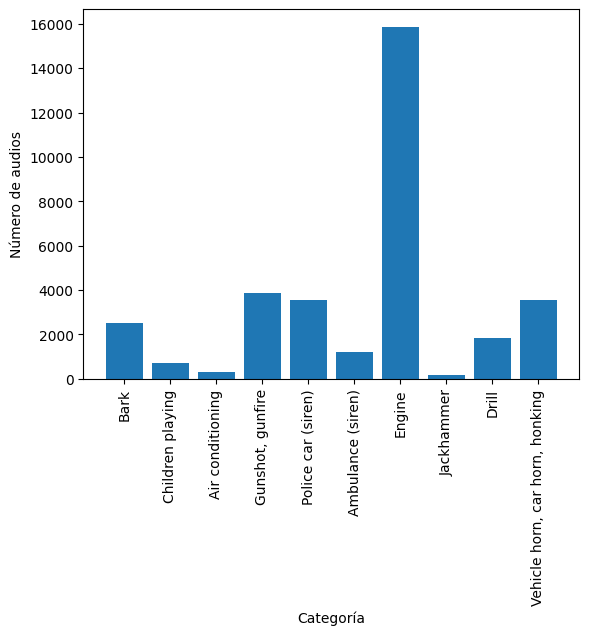

In [77]:
idx, cuentas = np.unique(df.indx, return_counts=True)
plt.bar(x=[indx_to_lable[indx] for indx in idx], height=cuentas)
plt.xticks(rotation=90)
plt.xlabel('Categoría')
plt.ylabel('Número de audios')
plt.show()

In [78]:
from sklearn.model_selection import train_test_split

In [79]:
df_train, df_val = train_test_split(df, test_size=.2, random_state=SEED, shuffle=True, stratify=df.indx)

In [82]:
df_train.shape

(26827, 6)

In [83]:
df_val.shape

(6707, 6)

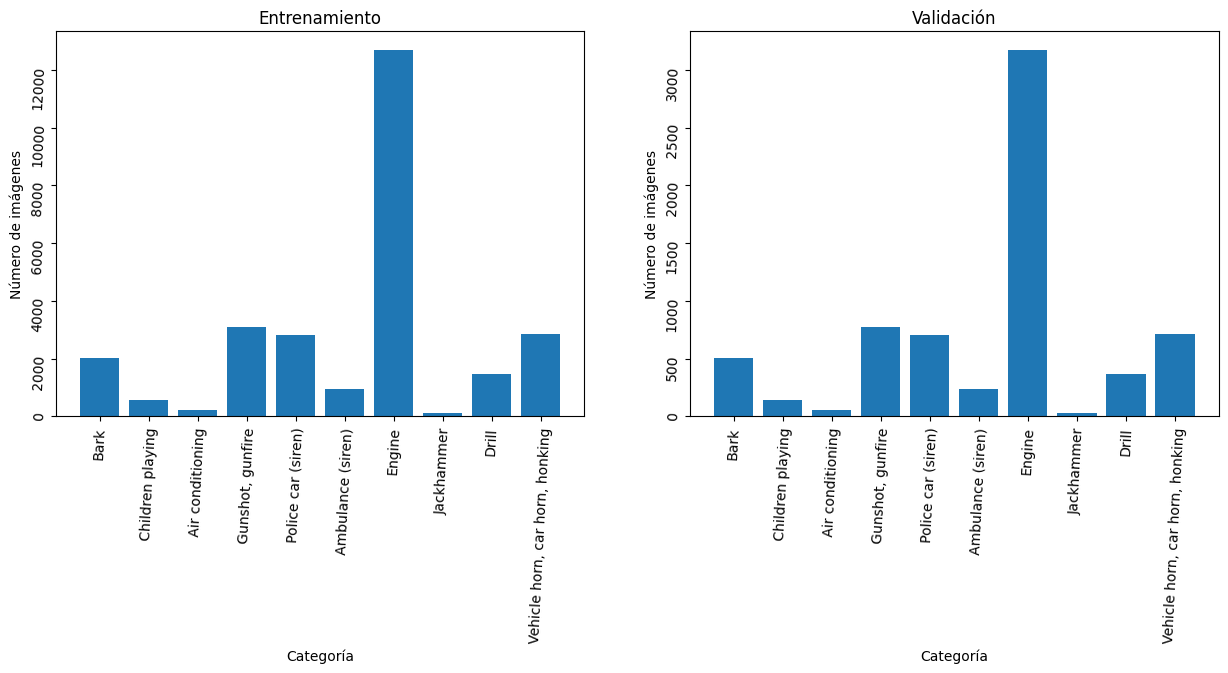

In [85]:
idx_ent, cuentas_ent = np.unique(df_train.indx, return_counts=True)
idx_val, cuentas_val = np.unique(df_val.indx, return_counts=True)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

axs[0].bar(x=[indx_to_lable[indx] for indx in idx_ent], height=cuentas_ent)
axs[0].set_title('Entrenamiento')
axs[0].set_xlabel('Categoría')
axs[0].set_ylabel('Número de imágenes')
axs[0].tick_params(rotation=87)

axs[1].bar(x=[indx_to_lable[indx] for indx in idx_val], height=cuentas_val)
axs[1].set_title('Validación')
axs[1].set_xlabel('Categoría')
axs[1].set_ylabel('Número de imágenes')
axs[1].tick_params(rotation=87)

plt.show()

## Descargamos los datos

In [87]:
root = './AudioSet/'

In [130]:
import subprocess

In [133]:
def download_and_trim_audio(video_id, start, end, output_dir):
    """
    Download the audio of a YouTube video and trim it to the specified duration using FFmpeg.
    """
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    # Construct the YouTube URL
    url = f"https://www.youtube.com/watch?v={video_id}"
    
    # Temporary download file path
    temp_file = os.path.join(output_dir, f"{video_id}.mp3")
    
    # Final trimmed output path
    output_file = os.path.join(output_dir, f"{video_id}.wav")
    
    # yt-dlp options for downloading audio
    ydl_opts = {
        'format': 'bestaudio/best',  # Download the best audio quality
        'outtmpl': temp_file,        # Save as a temporary file
        'quiet': True                # Suppress logging
    }
    
    # Download the audio
    with YoutubeDL(ydl_opts) as ydl:
        try:
            ydl.download([url])
        except Exception as e:
            print(f"Failed to download {video_id}: {e}")
            return
    
    # Use FFmpeg to trim and convert to WAV
    try:
        subprocess.run(
            [
                "ffmpeg",
                "-i", temp_file,             # Input file
                "-ss", str(start),           # Start time
                "-to", str(end),             # End time
                "-c:a", "pcm_s16le",         # WAV format
                "-ar", "16000",              # Sample rate
                "-ac", "1",                  # Mono channel
                output_file                  # Output file
            ],
            stdout=subprocess.DEVNULL,      # Suppress FFmpeg logs
            stderr=subprocess.DEVNULL
        )
        print(f"Trimmed audio saved to {output_file}")
    except Exception as e:
        print(f"Failed to trim audio for {video_id}: {e}")
    finally:
        # Clean up the temporary file
        if os.path.exists(temp_file):
            os.remove(temp_file)

In [ ]:
test = df_train.iloc[10]

video_id = test['# YTID']
start = test['start_seconds']
end   = test['end_seconds']
outputDir = './Data/AudioSet/train/'

print(f'{video_id = }, {start = }, {end = }, {outputDir = }')

video_id = 'StL9pFzRYEc', start = 9.0, end = 19.0, outputDir = 'AudioSet/train/'


In [135]:
download_and_trim_audio(video_id=video_id, start=start, end=end, output_dir=outputDir)

Trimmed audio saved to AudioSet/train/StL9pFzRYEc.wav    


In [99]:
df_train.iloc[0]

# YTID                      h_-Hp47CB28
start_seconds                     120.0
end_seconds                       130.0
positive_labels    "/m/01jwx6,/m/02mk9"
valid                              True
indx                                  6
Name: 1589218, dtype: object

### DataLoader

In [ ]:
from torch.utils.data import Dataset

In [ ]:
class AudioLoader(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        
    def __getitem__(self, idx):
        #